In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import numpy as np
import re

Extracted epochs: 10


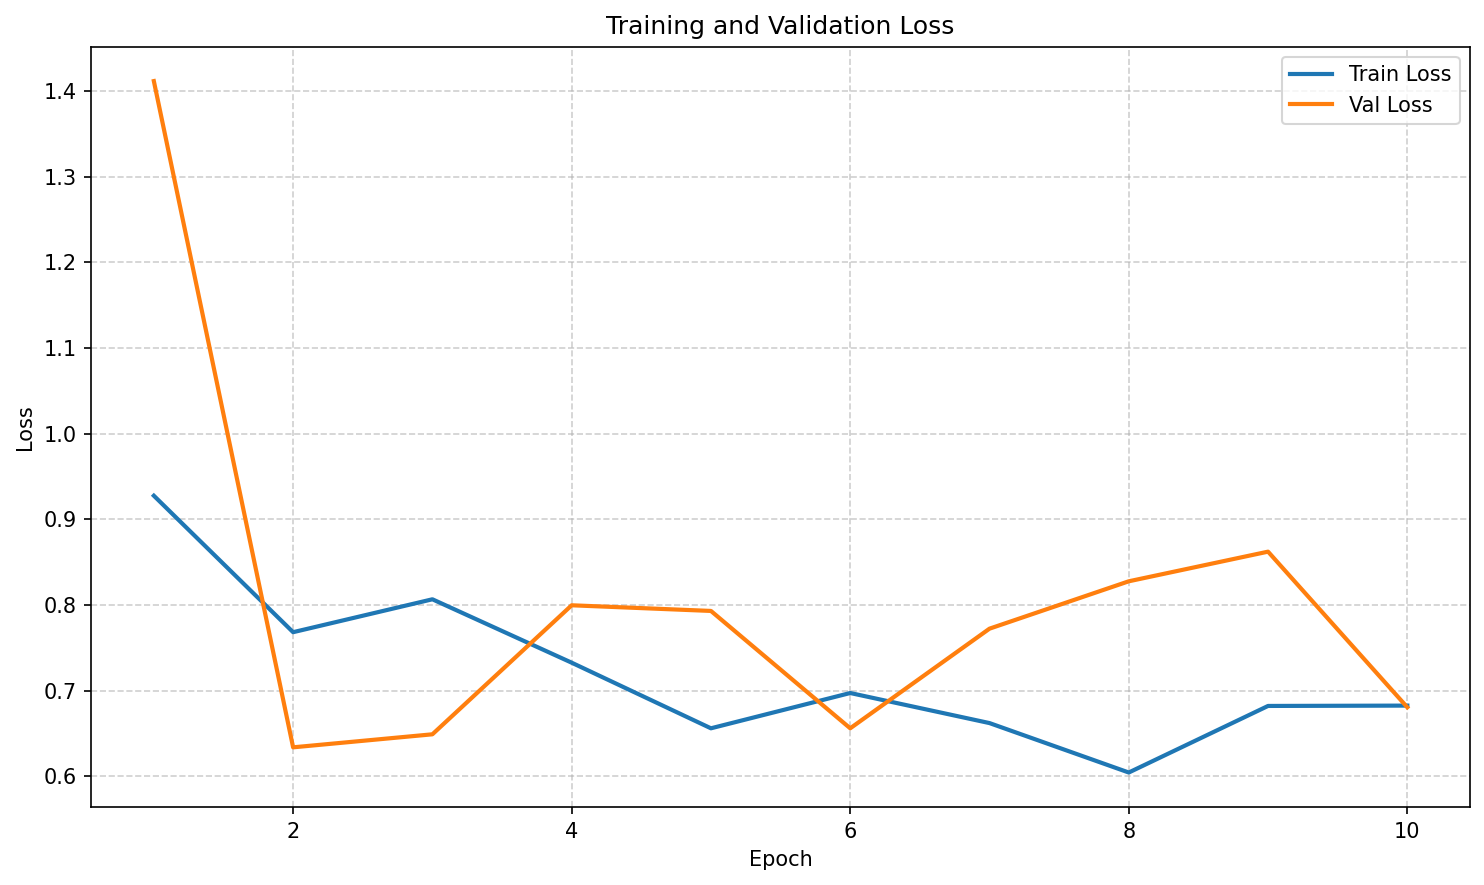

In [19]:
# Training and validation loss
log_path = "./logs/training_logs_8831684.log"

train_losses = []
val_losses = []

pattern = re.compile(r"Train Loss:\s*([0-9eE\.\-]+).*Val Loss:\s*([0-9eE\.\-]+)")

with open(log_path, "r") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            train_losses.append(float(m.group(1)))
            val_losses.append(float(m.group(2)))

print("Extracted epochs:", len(train_losses))
if len(train_losses) == 0:
    raise ValueError("No Train/Val loss found. Check log format / pattern.")

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

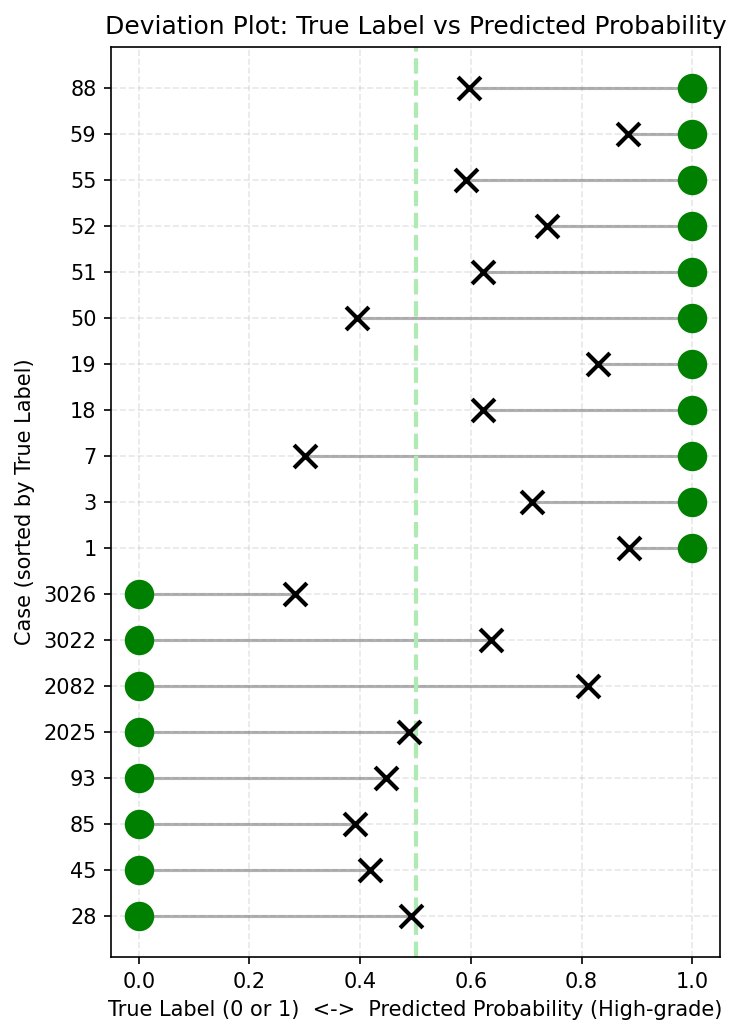

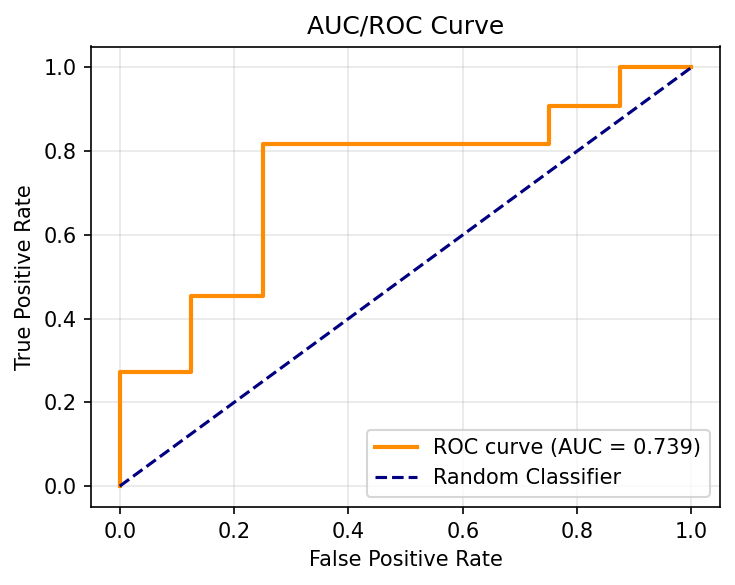


Computed AUC = 0.739


In [10]:
# Deviation plot (True label vs predicted probablity)
df = pd.read_csv("runs/run_20260216_105519/predictions.csv")

# Sort so true=0 cases appear first (optional but cleaner)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

# -----------------------------------------------------
# 1. Deviation Plot (True vs Probabilities)
# -----------------------------------------------------
plt.figure(figsize=(5,7), dpi=150)

for i, row in df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label = large green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability = small black X
    plt.scatter(
        row["prob_high_grade"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  <->  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2. AUC / ROC Curve
# -----------------------------------------------------
fpr, tpr, thresholds = roc_curve(df["true_label"], df["prob_high_grade"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4), dpi=150)
plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)
plt.plot(
    [0, 1], [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC/ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComputed AUC = {roc_auc:.3f}")

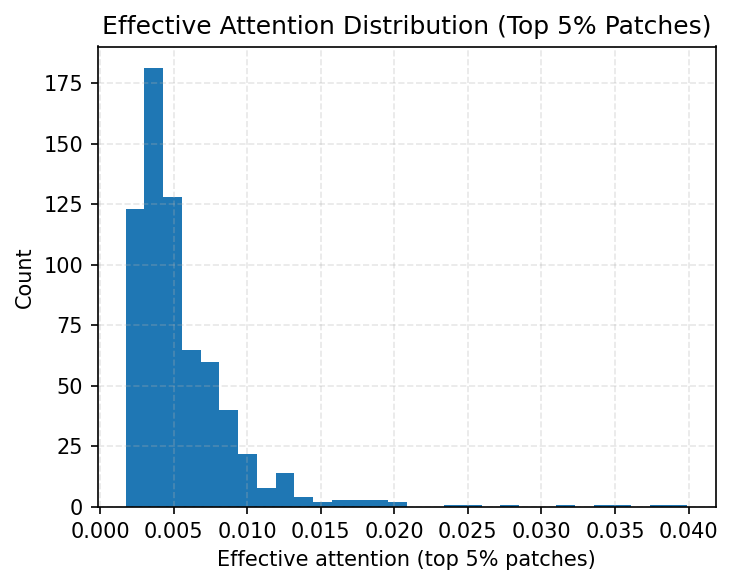

In [11]:
# Effective attention score distribution of patches
attn = pd.read_csv("runs/run_20260216_105519/attention_analysis/top_effective_patches_per_case_5.0pct.csv")

plt.figure(figsize=(5,4), dpi=150)
plt.hist(attn["effective_weight"], bins=30)
plt.xlabel("Effective attention (top 5% patches)")
plt.ylabel("Count")
plt.title("Effective Attention Distribution (Top 5% Patches)")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

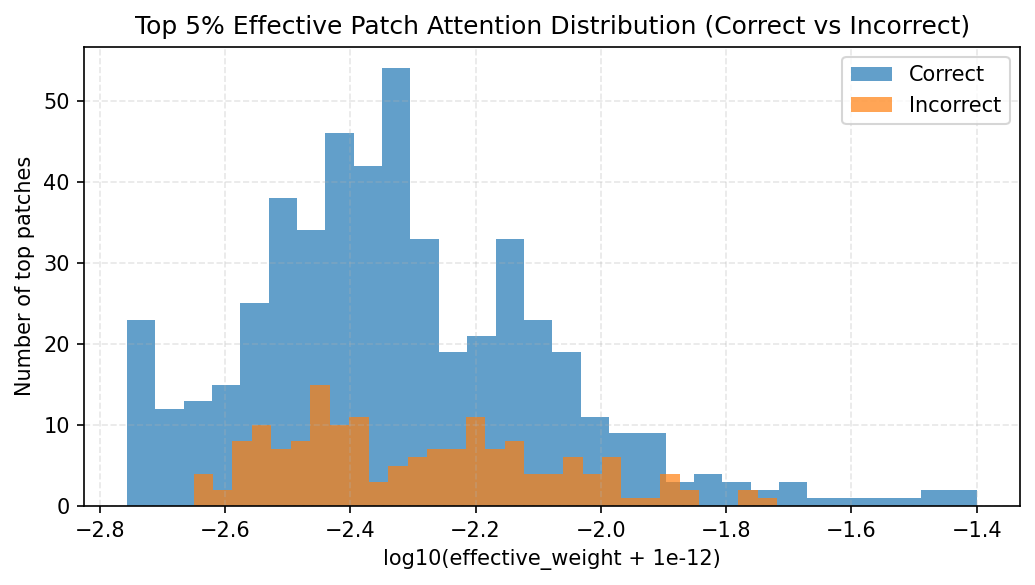

In [ ]:
attn["is_correct"] = (attn["true_label"] == attn["pred_label"]).astype(int)

attn["log_eff"] = np.log10(attn["effective_weight"] + 1e-12)

plt.figure(figsize=(7,4), dpi=150)
plt.hist(attn.loc[attn["is_correct"]==1, "log_eff"], bins=30, alpha=0.7, label="Correct")
plt.hist(attn.loc[attn["is_correct"]==0, "log_eff"], bins=30, alpha=0.7, label="Incorrect")
plt.xlabel("log10(effective_weight + 1e-12)")
plt.ylabel("Number of top patches")
plt.title("Top 5% Effective Patch Attention Distribution (Correct vs Incorrect)")
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
attention_summary_path = "runs/run_20260216_105519/attention_analysis/attention_summary.txt"

data = []
current_case = None
capture = False

with open(attention_summary_path, "r") as f:
    for line in f:
        line = line.strip()

        m = re.match(r"Case\s+(\d+):", line)
        if m:
            current_case = int(m.group(1))
            capture = False
            continue

        if "Stain-level attention" in line:
            capture = True
            continue

        if capture and ":" in line and current_case is not None:
            k, v = line.split(":", 1)
            try:
                data.append([current_case, k.strip(), float(v.strip())])
            except:
                pass

attn_df = pd.DataFrame(data, columns=["case_id", "stain", "attention_weight"])


/var/folders/zd/5blhwzjn431g7gv2bk59fvc00000gn/T/ipykernel_2949/3911079547.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


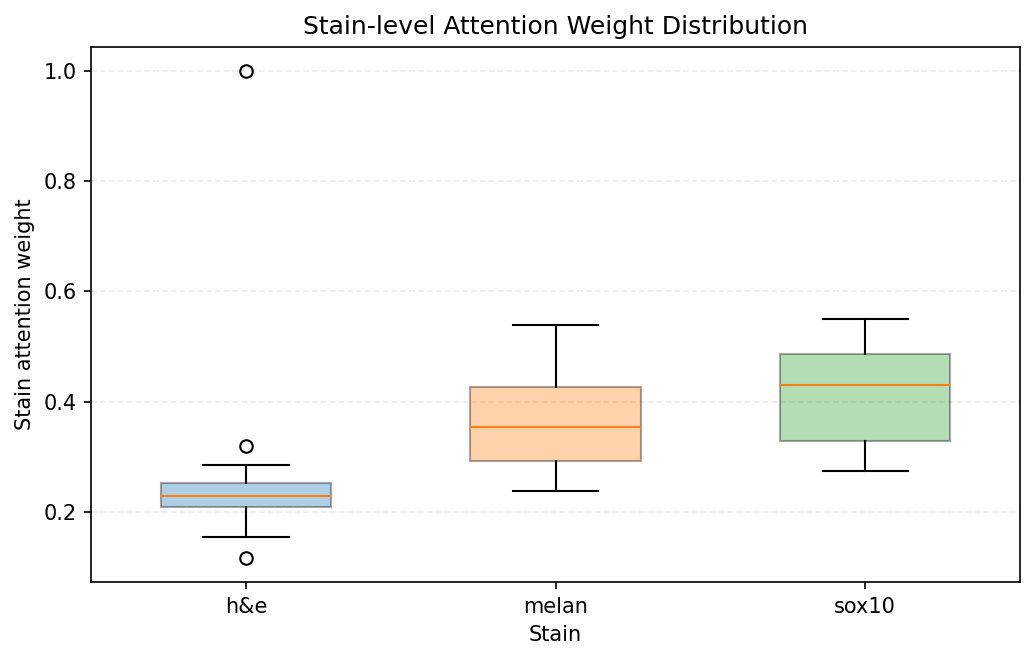

In [ ]:
stains = sorted(attn_df["stain"].unique())
box_data = [attn_df.loc[attn_df["stain"] == s, "attention_weight"].values for s in stains]

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

bp = ax.boxplot(
    box_data,
    labels=stains,
    showfliers=True,
    patch_artist=True,  
    widths=0.55
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, box in enumerate(bp["boxes"]):
    box.set(facecolor=colors[i % len(colors)], alpha=0.35, edgecolor="black", linewidth=1.0)


ax.set_xlabel("Stain")
ax.set_ylabel("Stain attention weight")
ax.set_title("Stain-level Attention Weight Distribution")
ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show()


In [23]:
case_total = attn.groupby("case_id").size().rename("n_top_patches")

slice_counts = (
    attn.groupby(["case_id","stain","slice_idx"])
        .size()
        .rename("n_in_slice")
        .reset_index()
)
top_slice = (
    slice_counts.groupby("case_id")["n_in_slice"]
                .max()
                .rename("max_in_slice")
)

stats = pd.concat([case_total, top_slice], axis=1).reset_index()
stats["top_slice_share"] = stats["max_in_slice"] / stats["n_top_patches"]

labels = (
    attn.groupby("case_id")[["true_label","pred_label"]]
        .first()
        .reset_index()
)

stats = stats.merge(labels, on="case_id", how="left")
stats["is_correct"] = (stats["true_label"] == stats["pred_label"]).astype(int)


/var/folders/zd/5blhwzjn431g7gv2bk59fvc00000gn/T/ipykernel_2949/2812814434.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


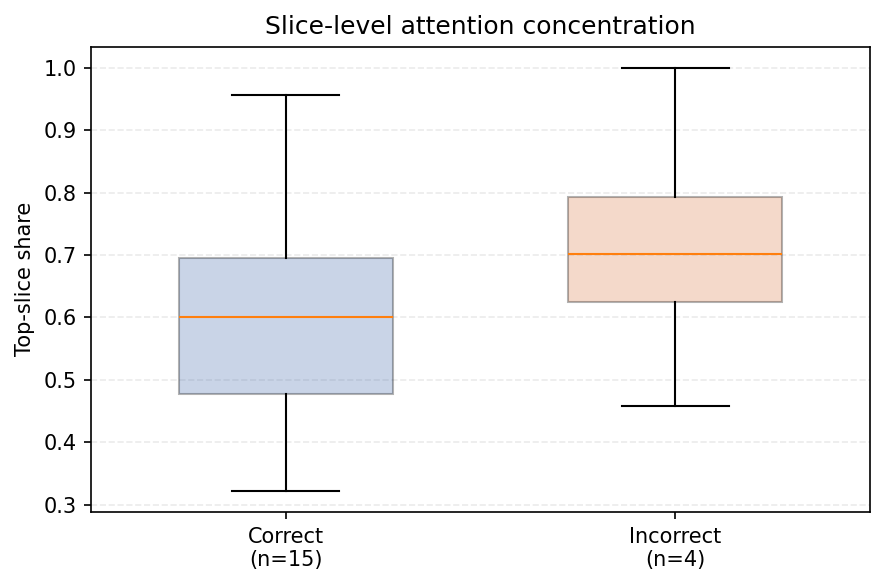

In [ ]:
plt.figure(figsize=(6,4), dpi=150)
ax = plt.gca()

data_correct = stats.loc[stats["is_correct"]==1, "top_slice_share"].dropna().values
data_incorrect = stats.loc[stats["is_correct"]==0, "top_slice_share"].dropna().values

bp = ax.boxplot(
    [data_correct, data_incorrect],
    labels=["Correct", "Incorrect"],
    showfliers=True,
    patch_artist=True, 
    widths=0.55
)

colors = ["#4C72B0", "#DD8452"]
for i, box in enumerate(bp["boxes"]):
    box.set(facecolor=colors[i], alpha=0.30, edgecolor="black", linewidth=1.0)

ax.set_ylabel("Top-slice share")
ax.set_title("Slice-level attention concentration")

ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)


ax.set_xticklabels([
    f"Correct\n(n={len(data_correct)})",
    f"Incorrect\n(n={len(data_incorrect)})"
])

plt.tight_layout()
plt.show()


In [ ]:
# correctness
attn["correct"] = (attn["true_label"] == attn["pred_label"])

# columns to show
cols = ["case_id", "stain", "slice_idx", "patch_idx", "effective_weight"]

def show_top_low(name, mask, k=10):
    g = attn.loc[mask, cols].copy()
    print("\n" + "="*60)
    print(name, f"(n={len(g)})")
    print("="*60)

    if len(g) == 0:
        return

    high = g.sort_values("effective_weight", ascending=False).head(k)
    low  = g.sort_values("effective_weight", ascending=True).head(k)

    print("\nTop 10 HIGH attention patches (by effective_weight):")
    print(high.to_string(index=False))

    print("\nTop 10 LOW attention patches (by effective_weight):")
    print(low.to_string(index=False))


show_top_low("Correct Benign (true=0, pred=0)",
             (attn["correct"]) & (attn["true_label"] == 0))

show_top_low("Correct High-Grade (true=1, pred=1)",
             (attn["correct"]) & (attn["true_label"] == 1))





Correct Benign (true=0, pred=0) (n=167)

Top 10 HIGH attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
      45 melan          0         12          0.039925
      45 melan          0         41          0.037612
      45 melan          0         11          0.035631
      45 melan          0         42          0.031058
      45 sox10          0          1          0.027889
      45 sox10          0         17          0.025698
    3026 melan          1          7          0.015446
    3026 melan          1         17          0.012731
    3026 melan          1         13          0.012425
    2025 melan          0         38          0.011882

Top 10 LOW attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
      28 sox10          0         83          0.002789
      28 melan          0          3          0.002790
      28 sox10          0         22          0.002792
      28 melan          0  

In [ ]:
show_top_low("Incorrect Benign (true=0, pred=1)",
             (~attn["correct"]) & (attn["true_label"] == 0))

show_top_low("Incorrect High-Grade (true=1, pred=0)",
             (~attn["correct"]) & (attn["true_label"] == 1))


Incorrect Benign (true=0, pred=1) (n=56)

Top 10 HIGH attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
    3022 melan          0         69          0.016672
    3022 melan          0         55          0.013053
    3022 melan          0         75          0.010596
    3022 melan          0         57          0.009831
    3022 melan          0         49          0.009693
    3022 melan          0         76          0.009325
    3022 melan          0         61          0.009119
    3022 melan          0          9          0.009097
    3022 melan          0         13          0.007806
    3022 melan          0         90          0.007519

Top 10 LOW attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
    2082   h&e          2         22          0.003445
    2082   h&e          0        105          0.003476
    2082   h&e          0         12          0.003530
    2082   h&e          2 

In [ ]:
slice_stats = (
    attn.groupby("case_id")
        .apply(lambda d: pd.Series({
            "true_label": d["true_label"].iloc[0],
            "pred_label": d["pred_label"].iloc[0],
            "num_top_patches": len(d),
            "num_unique_slices": d[["stain","slice_idx"]].drop_duplicates().shape[0]
        }))
        .reset_index()
)

slice_stats["slice_concentration"] = 1 / slice_stats["num_unique_slices"]


slice_stats["correct"] = (slice_stats["true_label"] == slice_stats["pred_label"])

slice_stats_correct = slice_stats[slice_stats["correct"]].copy()
slice_stats_incorrect = slice_stats[~slice_stats["correct"]].copy()

slice_stats_correct


,case_id,true_label,pred_label,num_top_patches,num_unique_slices,slice_concentration,correct
0,1,1,1,22,3,0.333333,True
1,3,1,1,43,3,0.333333,True
3,18,1,1,46,3,0.333333,True
4,19,1,1,87,6,0.166667,True
5,28,0,0,52,3,0.333333,True
6,45,0,0,6,2,0.500000,True
8,51,1,1,37,4,0.250000,True
9,52,1,1,28,2,0.500000,True
10,55,1,1,44,5,0.200000,True
11,59,1,1,18,3,0.333333,True


In [37]:
slice_stats_incorrect

,case_id,true_label,pred_label,num_top_patches,num_unique_slices,slice_concentration,correct
2,7,1,0,25,2,0.500000,False
7,50,1,0,83,6,0.166667,False
16,2082,0,1,29,2,0.500000,False
17,3022,0,1,27,1,1.000000,False


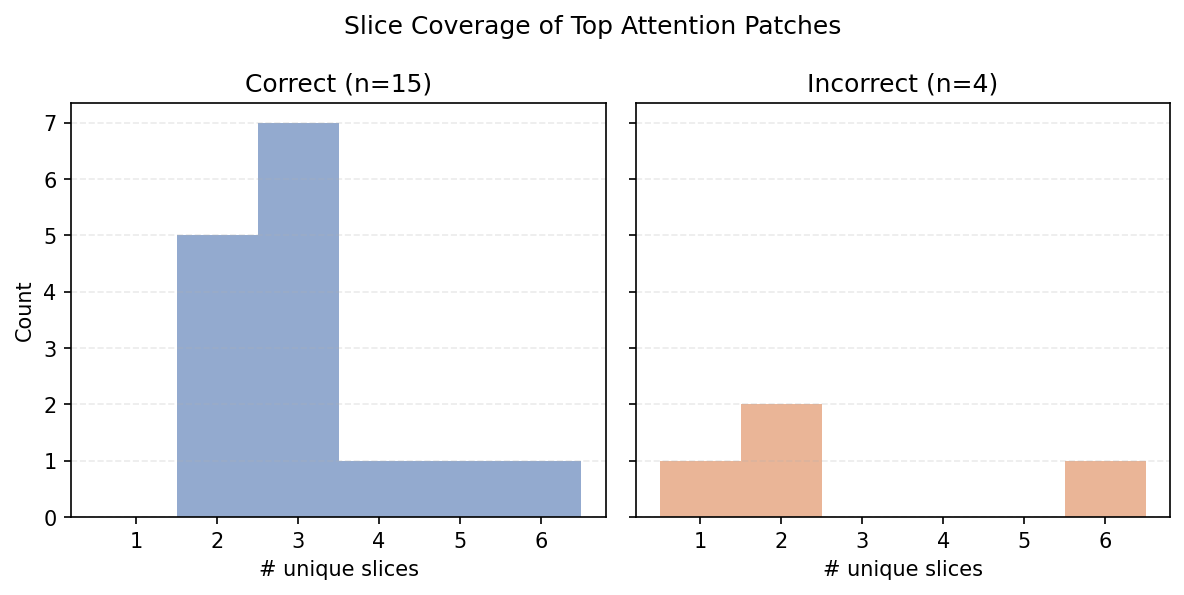

In [ ]:

x1 = slice_stats_correct["num_unique_slices"].dropna().values
x2 = slice_stats_incorrect["num_unique_slices"].dropna().values

max_val = max(x1.max(), x2.max())
bins = np.arange(1, max_val + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=150, sharey=True)

# --- Correct ---
axes[0].hist(x1, bins=bins, alpha=0.6, color="#4C72B0")
axes[0].set_title(f"Correct (n={len(x1)})")
axes[0].set_xlabel("# unique slices")
axes[0].set_ylabel("Count")
axes[0].set_xticks(np.arange(1, max_val + 1))
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

# --- Incorrect ---
axes[1].hist(x2, bins=bins, alpha=0.6, color="#DD8452")
axes[1].set_title(f"Incorrect (n={len(x2)})")
axes[1].set_xlabel("# unique slices")
axes[1].set_xticks(np.arange(1, max_val + 1))
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

fig.suptitle("Slice Coverage of Top Attention Patches", fontsize=12)
plt.tight_layout()
plt.show()
